In [3]:
import geopandas as gpd
from pyogrio import read_info

path = "../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_2020.shp"
# adjust the path if your notebook is somewhere else; use an absolute path if unsure

info = read_info(path)
print(info["features"], "features")
print(info["fields"])
print(info["dtypes"])

head = gpd.read_file(path, rows=5)
print(head.drop(columns="geometry"))
print(head.crs)

941872 features
['fire_ID' 'lat' 'lon' 'size' 'perimeter' 'start_date' 'start_DOY'
 'end_date' 'end_DOY' 'duration' 'fire_line' 'spread' 'speed' 'direction'
 'direc_frac' 'MODIS_tile' 'landcover' 'landc_frac' 'GFED_regio']
['int32' 'float64' 'float64' 'float64' 'float64' 'object' 'int32' 'object'
 'int32' 'int32' 'float64' 'float64' 'float64' 'object' 'float64' 'object'
 'object' 'float64' 'int32']
   fire_ID      lat      lon  size  perimeter  start_date  start_DOY  \
0    76988 -20.0104 -61.4981  1.50       5.56  2020-05-04        125   
1    76989 -20.0020 -59.4640  0.43       2.78  2020-09-23        267   
2    76995 -20.0020 -57.7790  3.64       9.26  2020-09-25        269   
3    76996 -20.0020 -57.6238  0.21       1.85  2020-06-26        178   
4    77012 -20.0020 -56.8922  0.43       2.78  2020-06-08        160   

     end_date  end_DOY  duration  fire_line  spread  speed direction  \
0  2020-05-08      129         5       0.65    0.30   0.67     north   
1  2020-09-23      26

In [5]:
import geopandas as gpd, pandas as pd

base = "../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_{}.shp"
frames = []
for yr in (2019, 2020, 2021, 2022):
    df = gpd.read_file(base.format(yr), ignore_geometry=True)
    df["start_date"] = pd.to_datetime(df["start_date"])
    df["file_year"] = yr
    print(yr, len(df), df["start_date"].min().date(), df["start_date"].max().date())
    frames.append(df)

fires = pd.concat(frames, ignore_index=True)
print("duplicate fire_IDs across files:", fires["fire_ID"].duplicated().sum())
print(fires["landcover"].value_counts())
print(fires["size"].describe())

2019 883922 2018-07-01 2020-05-31
2020 941872 2019-07-01 2021-05-31
2021 811489 2020-07-01 2022-05-31
2022 799297 2021-07-01 2023-05-31
duplicate fire_IDs across files: 2533584
landcover
Savannas                       1403956
Grasslands                      942749
Croplands                       376933
Woody savannas                  332643
Evergreen Broadleaf forest      141256
Deciduous Broadleaf forest      111465
Mixed forest                     67234
Open shrublands                  30203
Unclassified                      9836
Water                             7743
Evergreen Needleleaf forest       4590
Closed shrublands                 3576
Urban and built-up                3248
Deciduous Needleleaf forest       1136
Fill Value                          12
Name: count, dtype: int64
count    3.436580e+06
mean     4.017334e+00
std      2.736845e+01
min      2.100000e-01
25%      2.100000e-01
50%      8.600000e-01
75%      2.360000e+00
max      1.796905e+04
Name: size, dtype: float64

In [6]:
sel = fires[
    (fires["start_date"] >= "2020-01-01") & (fires["start_date"] < "2022-01-01")
    & (fires["size"] >= 5)          # about 500 ha, if size is in km2
].copy()
print(len(sel))
print(sel.groupby("landcover").size().sort_values(ascending=False))

239428
landcover
Savannas                       102524
Grasslands                      77903
Croplands                       18545
Woody savannas                  16846
Deciduous Broadleaf forest       9034
Mixed forest                     6014
Evergreen Broadleaf forest       3570
Open shrublands                  3567
Closed shrublands                 476
Unclassified                      447
Evergreen Needleleaf forest       386
Water                              51
Urban and built-up                 37
Deciduous Needleleaf forest        28
dtype: int64


In [7]:
dups = fires[fires.duplicated("fire_ID", keep=False)]
g = dups.groupby("fire_ID").agg(
    n=("file_year", "size"),
    n_lat=("lat", "nunique"),
    n_start=("start_date", "nunique"),
    n_size=("size", "nunique"),
)
print(g["n"].value_counts())
print((g[["n_lat", "n_start", "n_size"]] > 1).mean())   # share of IDs whose fields differ

n
4    759867
2     72024
5     39384
3     12189
6         9
Name: count, dtype: int64
n_lat      1.000000
n_start    0.999973
n_size     0.978144
dtype: float64


In [8]:
before = len(fires)
fires_u = fires.drop_duplicates(
    subset=["lat", "lon", "start_date", "end_date", "size"]).copy()
print("rows before:", before, " after:", len(fires_u), " removed:", before - len(fires_u))

# create your own unique ID, since fire_ID can't serve as one
fires_u["uid"] = fires_u["file_year"].astype(str) + "_" + fires_u["fire_ID"].astype(str)
print("uid unique:", fires_u["uid"].is_unique)

rows before: 3436580  after: 3397170  removed: 39410
uid unique: True


In [9]:
forest = ["Evergreen Broadleaf forest", "Deciduous Broadleaf forest", "Mixed forest",
          "Evergreen Needleleaf forest", "Deciduous Needleleaf forest"]

sel = fires_u[
    (fires_u["start_date"] >= "2020-01-01") & (fires_u["start_date"] < "2022-01-01")
    & (fires_u["size"] >= 5)
    & (fires_u["landcover"].isin(forest))
    & (fires_u["landc_frac"] >= 0.5)
].copy()

print(len(sel))
print(sel.groupby("landcover").size())
print(sel.groupby("GFED_regio").size())
print(sel["size"].describe())

16240
landcover
Deciduous Broadleaf forest     7736
Deciduous Needleleaf forest      16
Evergreen Broadleaf forest     3048
Evergreen Needleleaf forest     349
Mixed forest                   5091
dtype: int64
GFED_regio
1      124
2      238
3      287
4       59
5     1986
6       15
7       10
8     2167
9     7161
10     181
11      79
12    3781
13      17
14     135
dtype: int64
count    16240.000000
mean        19.328871
std         43.430675
min          5.140000
25%          6.860000
50%         10.290000
75%         18.860000
max       2977.800000
Name: size, dtype: float64


In [10]:
strata = (sel.groupby(["GFED_regio", "landcover"]).size()
             .rename("n_fires").reset_index())
print(strata.sort_values(["GFED_regio", "n_fires"], ascending=[True, False]).to_string(index=False))

top = (sel.sort_values("size", ascending=False)
          .groupby(["GFED_regio", "landcover"]).head(3)
          .sort_values(["GFED_regio", "landcover", "size"], ascending=[True, True, False]))
print(top[["uid", "GFED_regio", "landcover", "lat", "lon",
           "start_date", "end_date", "size"]].to_string(index=False))

 GFED_regio                   landcover  n_fires
          1 Evergreen Needleleaf forest      108
          1                Mixed forest       15
          1  Deciduous Broadleaf forest        1
          2 Evergreen Needleleaf forest      145
          2  Deciduous Broadleaf forest       51
          2  Evergreen Broadleaf forest       30
          2                Mixed forest       12
          3  Evergreen Broadleaf forest      141
          3  Deciduous Broadleaf forest      127
          3                Mixed forest       19
          4  Evergreen Broadleaf forest       51
          4  Deciduous Broadleaf forest        8
          5  Evergreen Broadleaf forest     1569
          5  Deciduous Broadleaf forest      406
          5                Mixed forest        9
          5 Evergreen Needleleaf forest        2
          6 Evergreen Needleleaf forest        9
          6  Deciduous Broadleaf forest        4
          6                Mixed forest        2
          7 Evergree

In [11]:
import os
os.makedirs("../data/processed", exist_ok=True)
sel.to_parquet("../data/processed/forest_fires_2020_2021_attrs.parquet")

In [12]:
import geopandas as gpd, os

path = "../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_2020.shp"
pilot = gpd.read_file(path, engine="pyogrio", where="fire_ID = 112")

print(pilot.drop(columns="geometry").T)   # check start_date 2020-08-14, size 1206.04
print(pilot.total_bounds)                 # minx, miny, maxx, maxy
os.makedirs("../data/processed/pilot", exist_ok=True)
pilot.to_file("../data/processed/pilot/fire_2020_112.gpkg", driver="GPKG")

                                      0
fire_ID                             112
lat                             39.6938
lon                            -122.782
size                            1206.04
perimeter                        308.36
start_date                   2020-08-14
start_DOY                           227
end_date                     2020-09-27
end_DOY                             271
duration                             45
fire_line                         39.34
spread                             26.8
speed                              4.42
direction                     northwest
direc_frac                         0.37
MODIS_tile                       h08v05
landcover   Evergreen Needleleaf forest
landc_frac                          0.5
GFED_regio                            2
[-123.09298503   39.5125     -122.55808696   39.87916666]


In [15]:
import rasterio
from rasterio.windows import from_bounds

url = "https://glad.geog.umd.edu/Potapov/Forest_height_2019/Forest_height_2019_NAM.tif"
west, south, east, north = -123.093, 39.5125, -122.558, 39.8792

with rasterio.open(url) as src:
    print(src.crs, src.res)
    win = from_bounds(west, south, east, north, src.transform)
    h = src.read(1, window=win)
print(h.shape)

EPSG:4326 (0.00025, 0.00025)
(1467, 2140)


In [16]:
import numpy as np
valid = h[h <= 60]          # 101 water, 102 snow/ice, 103 no data
print("share valid:", valid.size / h.size)
print("height percentiles (5, 25, 50, 75, 95):", np.percentile(valid, [5, 25, 50, 75, 95]))

share valid: 0.999959546152425
height percentiles (5, 25, 50, 75, 95): [ 0.  7. 15. 24. 34.]


In [4]:
import os, io, datetime as dt, requests, pandas as pd

os.environ["FIRMS_MAP_KEY"] = "694f59d089b8dab51c7e4c1094067706"
KEY = os.environ["FIRMS_MAP_KEY"]

bbox = "-123.15,39.46,-122.50,39.93"
start, end = dt.date(2020, 8, 1), dt.date(2020, 10, 15)

# check the exact source names and dates available first
print(requests.get(f"https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/{KEY}/all").text)

frames = []
for src in ["VIIRS_SNPP_SP", "VIIRS_NOAA20_SP"]:   # confirm names against the availability list
    d = start
    while d <= end:
        n = min(5, (end - d).days + 1)
        r = requests.get(f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{KEY}/{src}/{bbox}/{n}/{d}", timeout=60)
        if r.text.startswith("latitude"):
            df = pd.read_csv(io.StringIO(r.text)); df["source"] = src; frames.append(df)
        else:
            print(src, d, r.text[:100])
        d += dt.timedelta(days=n)

firms = pd.concat(frames, ignore_index=True)
os.makedirs("../data/firms", exist_ok=True)
firms.to_parquet("../data/firms/pilot_2020_112.parquet")
print(len(firms)); print(firms[["acq_date", "frp", "confidence", "daynight"]].describe(include="all"))

data_id,min_date,max_date
MODIS_NRT,2026-07-01,2026-10-05
MODIS_SP,2000-11-01,2026-06-30
VIIRS_NOAA20_NRT,2026-07-01,2026-10-05
VIIRS_NOAA20_SP,2018-04-01,2026-06-30
VIIRS_NOAA21_NRT,2024-01-17,2026-10-05
VIIRS_SNPP_NRT,2026-07-01,2026-10-05
VIIRS_SNPP_SP,2012-01-20,2026-06-30
LANDSAT_NRT,2022-06-20,2026-10-05
GOES_NRT,2022-08-09,2026-10-05
BA_MODIS,2000-11-01,2026-07-01
BA_VIIRS,2012-03-01,2026-07-01
59054
          acq_date       frp confidence daynight
count        59054  59054.00      59054    59054
unique          57   5579.00          3        2
top     2020-08-20      1.48          n        N
freq          4699    133.00      52747    39174


In [5]:
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize

fire = gpd.read_file("../data/processed/pilot/fire_2020_112.gpkg")
w, s, e, n = fire.total_bounds
base = "../data/tyukavina/NAM_fire_forest_loss_2001-25{}.tif"

arrs = {}
for tag in ["", "_annual"]:
    with rasterio.open(base.format(tag)) as src:
        print(tag or "base", src.crs, src.res, src.dtypes[0], src.nodata)
        win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
        arrs[tag] = src.read(1, window=win)
        tr = src.window_transform(win)

assert arrs[""].shape == arrs["_annual"].shape
mask = rasterize([(g, 1) for g in fire.geometry], out_shape=arrs[""].shape,
                 transform=tr, fill=0, dtype="uint8").astype(bool)

for tag, a in arrs.items():
    v, c = np.unique(a[mask], return_counts=True)
    print(tag or "base", dict(zip(v.tolist(), c.tolist())))
print(pd.crosstab(arrs[""][mask], arrs["_annual"][mask]))

base EPSG:4326 (0.00025, 0.00025) uint8 None
_annual EPSG:4326 (0.00025, 0.00025) uint8 None
base {0: 826585, 1: 59007, 2: 28273, 3: 57862, 4: 1059831}
_annual {0: 913865, 1: 5220, 2: 290, 3: 12909, 4: 10912, 5: 1662, 6: 11917, 7: 19979, 8: 10418, 9: 2480, 10: 623, 11: 46, 12: 11021, 13: 4376, 14: 761, 15: 3, 16: 123, 17: 49, 18: 643, 19: 595, 20: 708421, 21: 308929, 22: 4636, 23: 1308, 24: 369, 25: 3}
col_0      0     1    2      3     4     5      6      7     8     9   ...  \
row_0                                                                  ...   
0      826585     0    0      0     0     0      0      0     0     0  ...   
1       59007     0    0      0     0     0      0      0     0     0  ...   
2       28273     0    0      0     0     0      0      0     0     0  ...   
3           0   604  228    591  2336  1002   1279   4676  1000  1100  ...   
4           0  4616   62  12318  8576   660  10638  15303  9418  1380  ...   

col_0   16  17   18   19      20      21    22 

In [6]:
firms = pd.read_parquet("../data/firms/pilot_2020_112.parquet")
pts = gpd.GeoDataFrame(firms, geometry=gpd.points_from_xy(firms.longitude, firms.latitude), crs=4326)

poly = fire.to_crs(32610).buffer(500).to_crs(4326).iloc[0]   # fire polygon plus a 500 m margin
inside = pts[pts.within(poly) & (pts["confidence"] != "l")]
print(len(pts), "->", len(inside))
print("first/last detection:", inside.acq_date.min(), inside.acq_date.max())

daily = inside.groupby("acq_date").agg(n=("frp", "size"), frp_sum=("frp", "sum"), frp_max=("frp", "max"))
print(daily.to_string())
print(inside["frp"].describe())

59054 -> 35162
first/last detection: 2020-08-16 2020-10-12
               n    frp_sum  frp_max
acq_date                            
2020-08-16    11    1201.74   390.78
2020-08-17   118    1764.38   154.56
2020-08-18   189    3289.49   263.48
2020-08-19  3221  105085.56   670.48
2020-08-20  3712   88971.65  2051.62
2020-08-21  1841   26414.26   378.43
2020-08-22  1321   18324.92   248.89
2020-08-23  1466   19622.25   435.63
2020-08-24   335   10501.98   748.89
2020-08-25   953    4568.72   212.04
2020-08-26   582    2681.15    90.22
2020-08-27   711    8211.79   183.64
2020-08-28   856    6635.35   166.07
2020-08-29   687    3426.29    52.88
2020-08-30   721    4074.77    73.20
2020-08-31   979   11456.20   256.01
2020-09-01  1384   28101.35   793.28
2020-09-02  1090    9560.25   234.85
2020-09-03   670    4747.44   120.62
2020-09-04   741    8691.91   176.52
2020-09-05  1466   37488.23   509.80
2020-09-06   998   10369.63   221.63
2020-09-07  1225   24641.17   512.49
2020-09-08  2652

In [19]:
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling

fire = gpd.read_file("../data/processed/pilot/fire_2020_112.gpkg")
inner = fire.to_crs(32610).buffer(-500).to_crs(4326)        # burn minus outer 500 m

pad = 0.15
w, s, e, n = fire.total_bounds
w, s, e, n = w - pad, s - pad, e + pad, n + pad

# --- CCI biomass (100 m grid) ---
agb = {}
for yr in (2019, 2021, 2022):
    f = f"../data/cci_agb/N40W130_ESACCI-BIOMASS-L4-AGB-MERGED-100m-{yr}-fv6.0.tif"
    with rasterio.open(f) as src:
        win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
        agb[yr] = src.read(1, window=win, masked=True).astype("float64").filled(np.nan)
        tr_ref = src.window_transform(win)
shape = agb[2019].shape

m_inner = rasterize([(g, 1) for g in inner.geometry], out_shape=shape,
                    transform=tr_ref, fill=0, dtype="uint8").astype(bool)
valid = (np.isfinite(agb[2019]) & np.isfinite(agb[2021]) & np.isfinite(agb[2022]) & (agb[2019] > 10))

# --- Tyukavina fire-loss layers (30 m grid), same window ---
base = "../data/tyukavina/NAM_fire_forest_loss_2001-25{}.tif"
t = {}
for tag in ["", "_annual"]:
    with rasterio.open(base.format(tag)) as src:
        win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
        t[tag] = src.read(1, window=win)
        tr_t = src.window_transform(win)

fire_px  = np.isin(t[""], [3, 4])
this_fire = fire_px & np.isin(t["_annual"], [20, 21])                     # 2020 or 2021
other_fire = fire_px & (np.isin(t["_annual"], list(range(1, 20))) | np.isin(t["_annual"], [22, 23, 24, 25]))

def to_biomass_grid(a):
    out = np.zeros(shape, dtype="float32")
    reproject(a.astype("float32"), out, src_transform=tr_t, src_crs="EPSG:4326",
              dst_transform=tr_ref, dst_crs="EPSG:4326", resampling=Resampling.average)
    return out

frac  = to_biomass_grid(this_fire)    # share of each 100 m cell flagged as loss from this fire
prior = to_biomass_grid(other_fire)   # share flagged as loss from other years' fires

m = m_inner & valid & (prior <= 0.05)
print("cells kept:", int(m.sum()), "of", int((m_inner & valid).sum()))

d = pd.DataFrame({"frac": frac[m], "a19": agb[2019][m], "a21": agb[2021][m], "a22": agb[2022][m]})
d["bin"] = pd.cut(d["frac"], [-0.001, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0])
g = d.groupby("bin", observed=True)
out = g[["a19", "a21", "a22"]].sum()
out["n"] = g.size()
out["loss21"] = 1 - out["a21"] / out["a19"]
out["loss22"] = 1 - out["a22"] / out["a19"]
print(out[["n", "loss21", "loss22"]])

cells kept: 111521 of 125856
                    n    loss21    loss22
bin                                      
(-0.001, 0.05]  24760  0.004990  0.043584
(0.05, 0.25]     9957  0.018839  0.038067
(0.25, 0.5]     10083  0.028075  0.050619
(0.5, 0.75]     11440  0.031689  0.045315
(0.75, 0.95]    15090  0.040014  0.065745
(0.95, 1.0]     40191  0.064791  0.104574


In [20]:
bins = [-0.001, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]

with rasterio.open("../data/cci_agb/N40W130_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2018-fv6.0.tif") as src:
    win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
    a18 = src.read(1, window=win, masked=True).astype("float64").filled(np.nan)

m2 = m & np.isfinite(a18)
d2 = pd.DataFrame({"frac": frac[m2], "a18": a18[m2], "a19": agb[2019][m2]})
d2["bin"] = pd.cut(d2["frac"], bins)
g2 = d2.groupby("bin", observed=True)[["a18", "a19"]].sum()
g2["loss_2018_to_2019"] = 1 - g2["a19"] / g2["a18"]
print(g2[["loss_2018_to_2019"]])

print(d.groupby("bin", observed=True)["a19"].mean())


                loss_2018_to_2019
bin                              
(-0.001, 0.05]          -0.034773
(0.05, 0.25]            -0.023821
(0.25, 0.5]             -0.021587
(0.5, 0.75]             -0.016288
(0.75, 0.95]            -0.015098
(0.95, 1.0]             -0.004145
bin
(-0.001, 0.05]    93.461026
(0.05, 0.25]      93.949081
(0.25, 0.5]       92.503124
(0.5, 0.75]       90.388024
(0.75, 0.95]      88.122531
(0.95, 1.0]       86.131746
Name: a19, dtype: float64


## Fire severity (dNBR) for the pilot fire

Uses Sentinel-2 via Earth Engine. One-time setup on the instance, if not already done:

```python
import ee
ee.Authenticate()   # opens a browser link once, then caches a token
```

Pre-fire image: a clear composite from the season before the fire started (2020-08-14), so July 2020.
Post-fire image: the same season one year later (July-August 2021), per the roadmap, so that normal seasonal change is not mistaken for fire damage.

In [5]:
import ee
ee.Authenticate()
ee.Initialize(project="tree-fire-510209")


Enter verification code:  4/1AXlqoi4A5s9-oHqCcQd1dCkoi6IepQrfYmfHWIsFW3IBJ6t5Uv-Vh7UEqNM



Successfully saved authorization token.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [7]:
import ee, geemap
import geopandas as gpd


fire = gpd.read_file("../data/processed/pilot/fire_2020_112.gpkg")
pad = 0.15
w_pad, s_pad, e_pad, n_pad = fire.total_bounds
w_pad, s_pad, e_pad, n_pad = w_pad - pad, s_pad - pad, e_pad + pad, n_pad + pad
aoi = ee.Geometry.Rectangle([w_pad, s_pad, e_pad, n_pad])

def mask_s2_clouds(img):
    qa = img.select("QA60")
    mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return img.updateMask(mask).divide(10000)

def nbr(img):
    return img.normalizedDifference(["B8", "B12"]).rename("NBR")

def composite(start, end):
    coll = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(aoi)
            .filterDate(start, end)
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
            .map(mask_s2_clouds))
    print(start, end, "images:", coll.size().getInfo())
    return nbr(coll.median())

nbr_pre = composite("2020-07-01", "2020-08-10")
nbr_post = composite("2021-07-01", "2021-08-31")
dnbr = nbr_pre.subtract(nbr_post).rename("dNBR").clip(aoi)

2020-07-01 2020-08-10 images: 54
2021-07-01 2021-08-31 images: 79


In [17]:
task = ee.batch.Export.image.toCloudStorage(
    image=dnbr,
    description="dnbr_2020_112",
    bucket="tree-fire-510209-data",
    fileNamePrefix="fire-impact-curves/data/severity/dnbr_2020_112",
    region=aoi,
    scale=30,
    maxPixels=1e9,
)
task.start()

In [18]:
import time
while task.active():
    print(task.status()["state"])
    time.sleep(15)
print(task.status())


RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
{'state': 'COMPLETED', 'description': 'dnbr_2020_112', 'priority': 100, 'creation_timestamp_ms': 1791279944947, 'update_timestamp_ms': 1791280311329, 'start_timestamp_ms': 1791279946903, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://console.developers.google.com/storage/browser/tree-fire-510209-data/fire-impact-curves/data/severity/'], 'attempt': 1, 'batch_eecu_usage_seconds': 1083.5233154296875, 'id': 'HMCGMSFTMJIOPORQYX5AV5Q2', 'name': 'projects/tree-fire-510209/operations/HMCGMSFTMJIOPORQYX5AV5Q2'}


In [21]:
from rasterio.warp import reproject, Resampling

with rasterio.open(out_path) as src:
    print(src.crs, src.res, src.shape)
    win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
    dnbr_arr = src.read(1, window=win, masked=True).astype("float64").filled(np.nan)
    tr_dnbr = src.window_transform(win)

dnbr_100m = np.full(shape, np.nan, dtype="float32")
reproject(np.nan_to_num(dnbr_arr, nan=-9999).astype("float32"), dnbr_100m,
          src_transform=tr_dnbr, src_crs="EPSG:4326",
          dst_transform=tr_ref, dst_crs="EPSG:4326", resampling=Resampling.average)
dnbr_100m[dnbr_100m < -100] = np.nan   # cells with no valid 30 m pixel underneath

print("dNBR percentiles (5,25,50,75,95):",
      np.nanpercentile(dnbr_100m[m], [5, 25, 50, 75, 95]))

d["dnbr"] = dnbr_100m[m]
sev_bins = [-1, 0.0, 0.1, 0.27, 0.66, 2.0]
sev_labels = ["unburnt/negative", "very low", "mild", "moderate", "severe"]
d["severity"] = pd.cut(d["dnbr"], sev_bins, labels=sev_labels)

g_sev = d.groupby("severity", observed=True)
out_sev = g_sev[["a19", "a21", "a22"]].sum()
out_sev["n"] = g_sev.size()
out_sev["loss21"] = 1 - out_sev["a21"] / out_sev["a19"]
out_sev["loss22"] = 1 - out_sev["a22"] / out_sev["a19"]
print(out_sev[["n", "loss21", "loss22"]])

EPSG:4326 (0.00026949458523585647, 0.00026949458523585647) (2477, 3099)
dNBR percentiles (5,25,50,75,95): [0.10791451 0.2729944  0.41652662 0.62109691 0.9045226 ]
                      n    loss21    loss22
severity                                   
unburnt/negative    915  0.233736  0.326634
very low           4144  0.036614  0.107022
mild              22214  0.010367  0.051305
moderate          60292  0.027777  0.044518
severe            23956  0.068334  0.115936


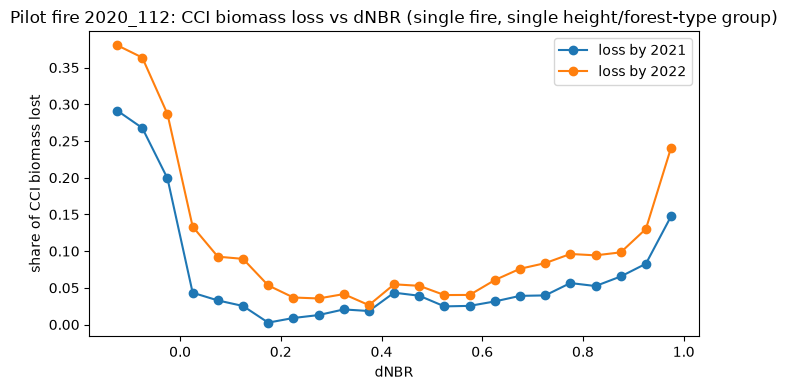

In [22]:
import matplotlib.pyplot as plt

step = 0.05
edges = np.arange(-0.2, 1.0 + step, step)
d["dnbr_bin"] = pd.cut(d["dnbr"], edges)
g_fine = d.groupby("dnbr_bin", observed=True)
curve = g_fine[["a19", "a21", "a22"]].sum()
curve["n"] = g_fine.size()
curve["loss21"] = 1 - curve["a21"] / curve["a19"]
curve["loss22"] = 1 - curve["a22"] / curve["a19"]
curve = curve[curve["n"] >= 50]   # drop bins with too few cells to trust
curve["mid"] = curve.index.map(lambda iv: iv.mid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["mid"], curve["loss21"], marker="o", label="loss by 2021")
ax.plot(curve["mid"], curve["loss22"], marker="o", label="loss by 2022")
ax.set_xlabel("dNBR")
ax.set_ylabel("share of CCI biomass lost")
ax.set_title("Pilot fire 2020_112: CCI biomass loss vs dNBR (single fire, single height/forest-type group)")
ax.legend()
fig.tight_layout()
fig.savefig("../data/processed/pilot/loss_vs_dnbr_pilot.png", dpi=150)
plt.show()